<a href="https://colab.research.google.com/github/Hadeed07/FlyRank-ML/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hadeed07/FlyRank-ML/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
!git clone https://github.com/Hadeed07/FlyRank-ML.git
import pandas as pd

fatal: destination path 'FlyRank-ML' already exists and is not an empty directory.


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [2]:
df = pd.read_csv('/content/FlyRank-ML/data/raw/content_refresh_anonymized.csv')

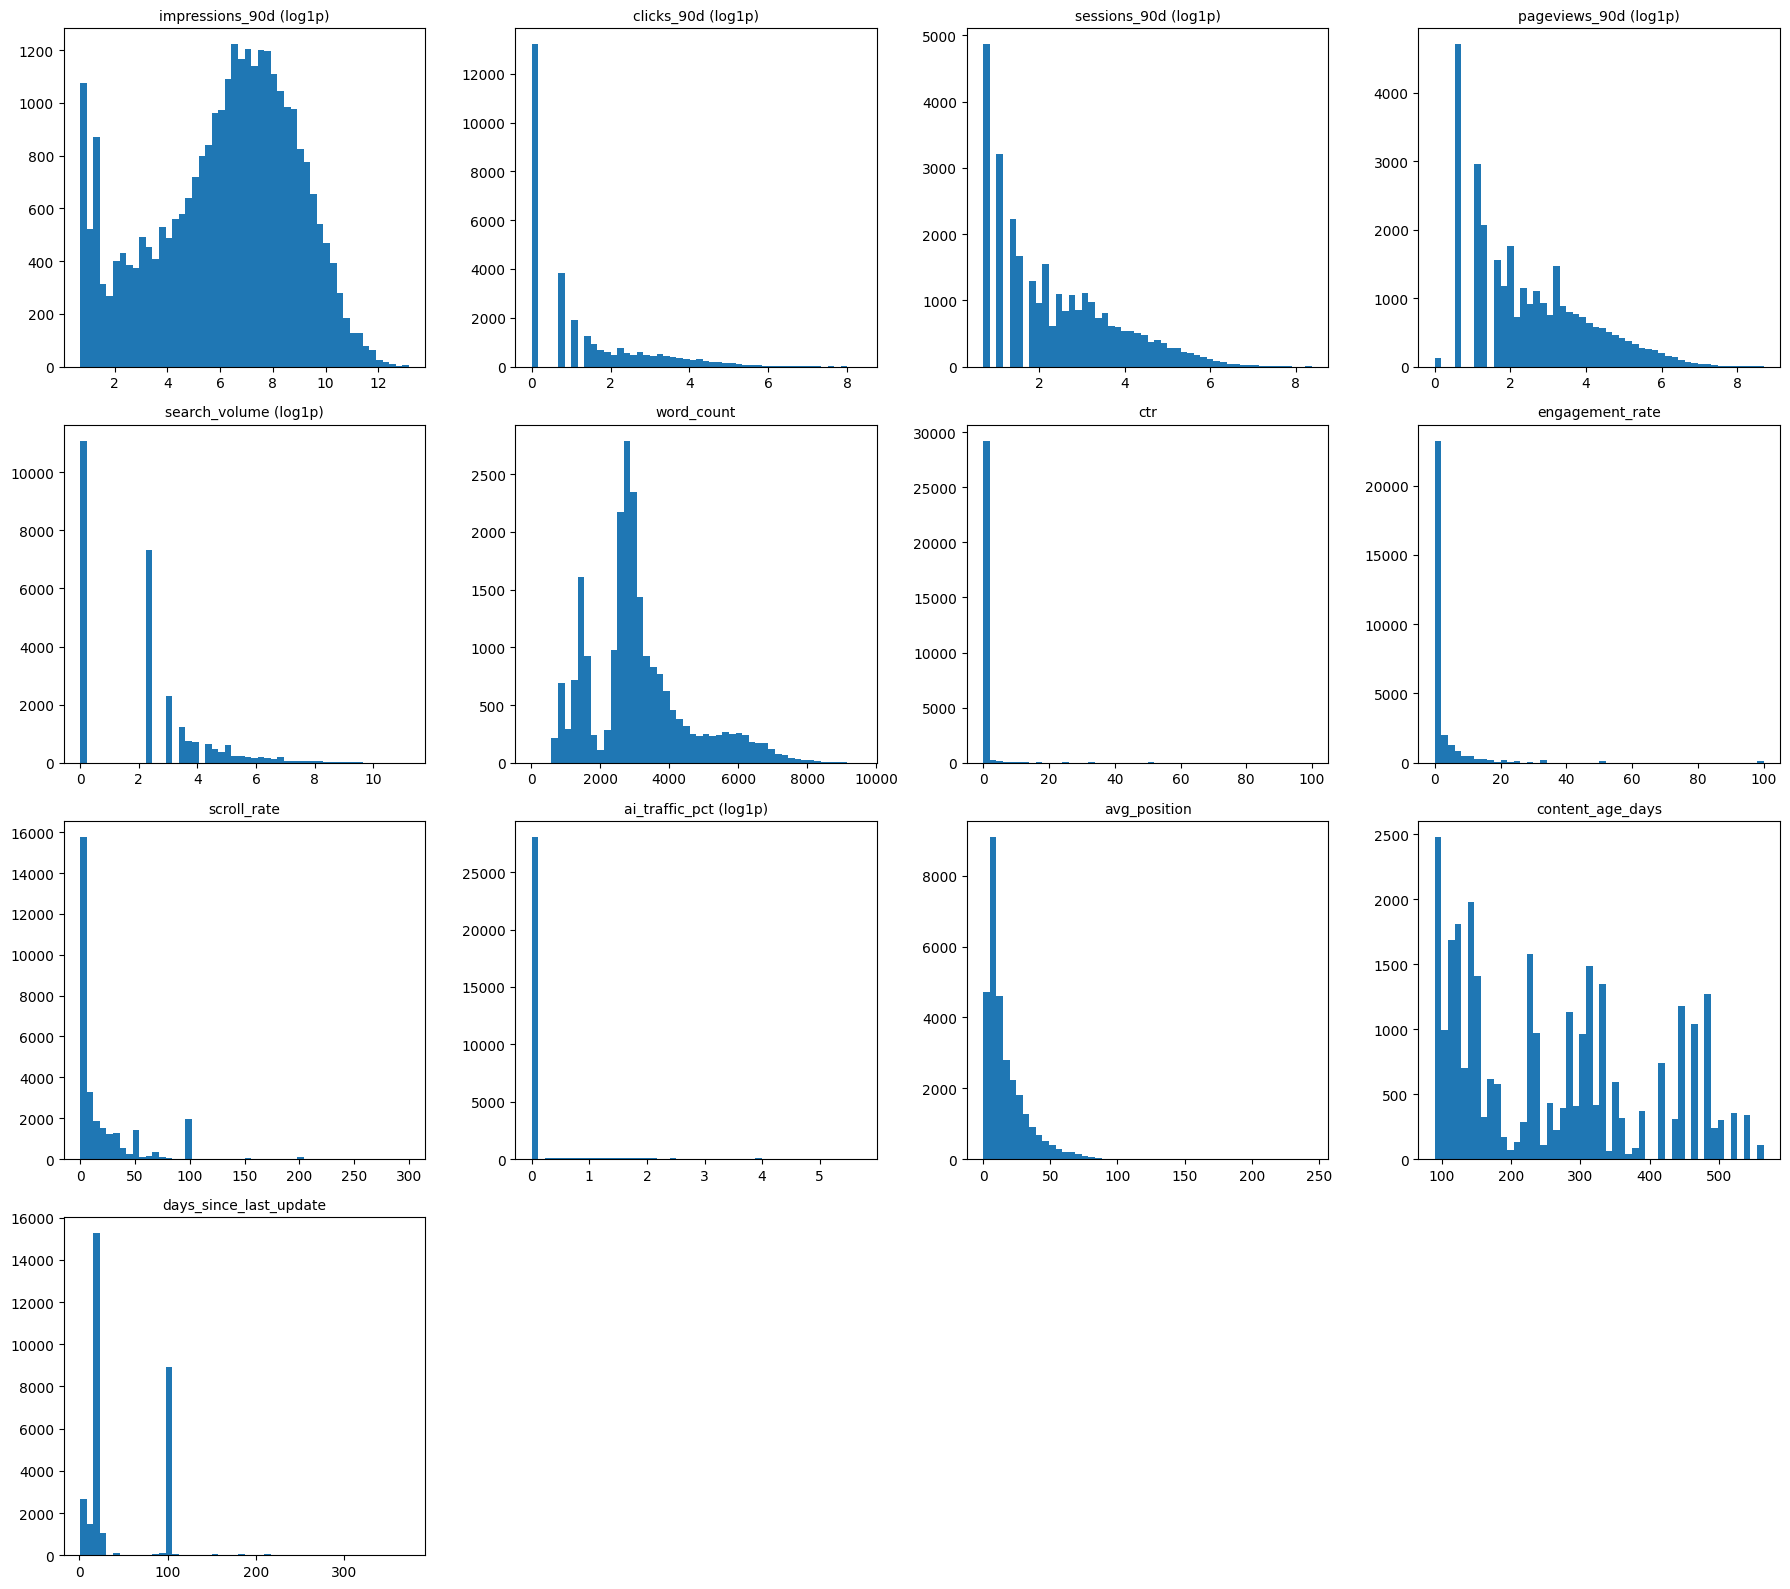

In [3]:
import matplotlib.pyplot as plt
import numpy as np

cols = ['impressions_90d', 'clicks_90d', 'sessions_90d', 'pageviews_90d',
        'search_volume', 'word_count', 'ctr', 'engagement_rate',
        'scroll_rate', 'ai_traffic_pct', 'avg_position',
        'content_age_days', 'days_since_last_update']

heavy_tailed = ['impressions_90d', 'clicks_90d', 'sessions_90d', 'pageviews_90d',
                 'search_volume', 'ai_traffic_pct']

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    data = df[col].dropna()
    if col in heavy_tailed:
        ax.hist(np.log1p(data), bins=50)
        ax.set_title(f'{col} (log1p)', fontsize=10)
    else:
        ax.hist(data, bins=50)
        ax.set_title(col, fontsize=10)

for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

`impressions_90d` and `clicks_90d` are heavily right-skewed — mean impressions (5,200) is over 7x the median (731), and the max (517,715) is one extreme outlier dragging the mean up. Same pattern for clicks: mean 16, median 1. A handful of pages carry most of the traffic; most pages are small. This is exactly the "few giants, long tail" shape the audit skill warns about — plain correlation on raw values would be dominated by those giants, so every test below uses weighted rates (total clicks / total impressions) or grouped medians instead of row-averaged means.

`word_count` is right-skewed but far less extreme (median 2,877 vs mean 3,108) — normal enough to use directly.

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Signal test # 1
AI-generated content perform differently depending upon which model wrote it by looking at the impressions anc clicks.

In [6]:
sub = df.dropna(subset=['model_used'])

# quick check first
print(sub.groupby('model_used')['impressions_90d'].agg(['median', 'count']))

# full weighted summary
def summarize(group):
    total_clicks = group['clicks_90d'].sum()
    total_impressions = group['impressions_90d'].sum()
    weighted_ctr = total_clicks / total_impressions * 100
    return pd.Series({
        'weighted_ctr': weighted_ctr,
        'median_impressions': group['impressions_90d'].median(),
        'n': len(group)
    })

print(sub.groupby('model_used').apply(summarize, include_groups=False))

                        median  count
model_used                           
gemini-2.5-flash         127.0   3665
gemini-3-flash-preview  1688.0  13271
gpt-4o-mini              153.0   4981
gpt-5-mini                24.0   1598
unknown                  106.5    752
                        weighted_ctr  median_impressions        n
model_used                                                       
gemini-2.5-flash            0.316872               127.0   3665.0
gemini-3-flash-preview      0.321575              1688.0  13271.0
gpt-4o-mini                 0.337140               153.0   4981.0
gpt-5-mini                  0.264073                24.0   1598.0
unknown                     0.271751               106.5    752.0


The conclusion at the model level: gpt-4o-mini is the strongest performer (0.34% weighted CTR), followed closely by gemini-3-flash-preview (0.32%) and gemini-2.5-flash (0.32%), with gpt-5-mini clearly the weakest (0.26%). The gap between best and worst is real but modest — about 0.07 percentage points, not a dramatic split.


The claim "AI-generated content performs differently depending on which model wrote it" is true, but the honest version of the finding is model-level, not provider-level. Provider is too coarse a grouping — it hides which specific model is actually driving the difference. A content team acting on "google beats openai" would deprioritize gpt-4o-mini output, which this data doesn't support at all.

### Signal # 2
Keyword articles outperform feedly/comparison articles.

In [12]:
# df['content_type'].isnull().sum()  It is already 0

# quick check first
print(df.groupby('content_type')['impressions_90d'].agg(['median', 'count']))

# full weighted summary
def summarize(group):
    total_clicks = group['clicks_90d'].sum()
    total_impressions = group['impressions_90d'].sum()
    weighted_ctr = total_clicks / total_impressions * 100
    return pd.Series({
        'weighted_ctr': weighted_ctr,
        'median_impressions': group['impressions_90d'].median(),
        'n': len(group)
    })

print(df.groupby('content_type').apply(summarize, include_groups=False))

                    median  count
content_type                     
comparison article   107.0    697
feedly article         4.0   2096
keyword article      955.0  27207
                    weighted_ctr  median_impressions        n
content_type                                                 
comparison article      0.096908               107.0    697.0
feedly article          0.568834                 4.0   2096.0
keyword article         0.309134               955.0  27207.0


**The conclusion**: the claim "keyword articles outperform feedly/comparison articles" is MIXED, and the two tables tell genuinely different stories depending on which number you look at.

By weighted CTR (conversion efficiency), the ranking is actually the opposite of the claim: feedly article (0.57%) > keyword article (0.31%) > comparison article (0.10%). Feedly articles convert impressions into clicks nearly twice as well as keyword articles do.

But by volume — median impressions and total reach — keyword articles dominate completely: 955 median impressions per page versus feedly's 4. Keyword articles are 27,207 of your 30,000 rows; they're carrying almost all of the site's actual search traffic, even though each individual page converts less efficiently.

### Signal # 3
High-CPC keywords convert to clicks better

In [13]:
from scipy.stats import spearmanr

sub = df[df['cpc'] > 0]  # cpc == 0 is a real value (low-value keyword), not missing — # filtering it out on purpose so the correlation measures
# "does cpc going up move ctr" among keywords that actually have a price
corr, p = spearmanr(sub['cpc'], sub['ctr'])
print(corr, p)

0.010106464845275186 0.4028676646978129


In [18]:
sub = sub.copy()
sub['cpc_bin'] = pd.qcut(sub['cpc'], 4, duplicates='drop')

print(sub.groupby('cpc_bin').apply(summarize, include_groups=False))

                              weighted_ctr  median_impressions       n
cpc_bin                                                               
(0.009000000000000001, 0.17]      0.312244               981.0  1725.0
(0.17, 0.85]                      0.294717               951.0  1714.0
(0.85, 2.18]                      0.291226               589.5  1704.0
(2.18, 100.36]                    0.278618               570.0  1710.0


/tmp/ipykernel_2802/1676076766.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sub.groupby('cpc_bin').apply(summarize, include_groups=False))


In [17]:
sub = df[df['cpc'] > 0].copy()  # cpc == 0 is a real value here (low-value keyword), not missing

# quick check first
sub['cpc_bin'] = pd.qcut(sub['cpc'], 4, duplicates='drop')
print(sub.groupby('cpc_bin')['impressions_90d'].agg(['median', 'count']))

# full weighted summary
def summarize(group):
    total_clicks = group['clicks_90d'].sum()
    total_impressions = group['impressions_90d'].sum()
    weighted_ctr = total_clicks / total_impressions * 100
    return pd.Series({
        'weighted_ctr': weighted_ctr,
        'median_impressions': group['impressions_90d'].median(),
        'n': len(group)
    })

print(sub.groupby('cpc_bin').apply(summarize, include_groups=False))

                              median  count
cpc_bin                                    
(0.009000000000000001, 0.17]   981.0   1725
(0.17, 0.85]                   951.0   1714
(0.85, 2.18]                   589.5   1704
(2.18, 100.36]                 570.0   1710
                              weighted_ctr  median_impressions       n
cpc_bin                                                               
(0.009000000000000001, 0.17]      0.312244               981.0  1725.0
(0.17, 0.85]                      0.294717               951.0  1714.0
(0.85, 2.18]                      0.291226               589.5  1704.0
(2.18, 100.36]                    0.278618               570.0  1710.0


/tmp/ipykernel_2802/426770131.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sub.groupby('cpc_bin')['impressions_90d'].agg(['median', 'count']))
/tmp/ipykernel_2802/426770131.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sub.groupby('cpc_bin').apply(summarize, include_groups=False))


Weighted CTR drifts gently downward as CPC rises — 0.31% in the cheapest bin down to 0.28% in the most expensive one. That's the opposite direction of the claim ("high-CPC keywords convert to clicks better"), though the drop is small enough (about 0.03 percentage points across the full range) that it's not worth calling it OPPOSITE outright

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. What this means in practice


Individual AI model choice matters more than provider choice — gpt-4o-mini
outperforms every gemini model tested, a signal that's invisible if you only
look at the provider-level average. Content type isn't a simple win/lose:
feedly articles convert better per page, but keyword articles are what
actually carry the site's traffic, so the right call depends on whether the
goal is efficiency or scale. CPC (paid-search value) has no bearing on
organic CTR and shouldn't factor into content-refresh prioritization.
Position tier does predict CTR reliably enough to anchor a benchmark — except
in the top_3 tier, where per-page volume is too thin to trust an individual
page's CTR against that benchmark without a volume check attached.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.